In [73]:
import pandas as pd
import numpy as np

cols = ['Product_id','Price','Sale','weight','resolution','ppi',
        'cpu_core','cpu_freq','internal_mem','ram',
        'RearCam','Front_Cam','battery','thickness']

df = pd.read_csv("Cellphone.csv", names=cols, header=0)

# Basic structure
print("Shape:", df.shape, "\n")
print(df.head(), "\n")
print(df.info())
print(df.describe().T, "\n")
print("\n Missing Values:")
print(df.isnull().sum(), "\n")
print("\n Duplicates:")
print(df.duplicated().sum(), "\n")   

Shape: (161, 14) 

   Product_id  Price  Sale  weight  resolution  ppi  cpu_core  cpu_freq  \
0         203   2357    10   135.0         5.2  424         8      1.35   
1         880   1749    10   125.0         4.0  233         2      1.30   
2          40   1916    10   110.0         4.7  312         4      1.20   
3          99   1315    11   118.5         4.0  233         2      1.30   
4         880   1749    11   125.0         4.0  233         2      1.30   

   internal_mem    ram  RearCam  Front_Cam  battery  thickness  
0          16.0  3.000    13.00        8.0     2610        7.4  
1           4.0  1.000     3.15        0.0     1700        9.9  
2           8.0  1.500    13.00        5.0     2000        7.6  
3           4.0  0.512     3.15        0.0     1400       11.0  
4           4.0  1.000     3.15        0.0     1700        9.9   

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
-

1. The dataset contains 161 rows and 14 numeric features, with no missing values and no duplicates, making it clean and ready for modeling.
2. The target variable Price ranges from *₹614* to *₹4361*, with a mean of ₹2215, showing a right‑skewed distribution due to a few high‑end devices.
3. Several features show large variance (e.g., Sale, battery, ppi), indicating a mix of low‑end, mid‑range, and premium devices.
4. Some features contain unrealistic zero values (e.g., cpu_core, cpu_freq, ram, internal_mem), which may require correction or removal.
5. Strong predictors of price are expected to be PPI, RAM, internal memory, CPU frequency, and camera specs, based on typical smartphone characteristics.
6. Outliers exist in battery capacity, resolution, weight, and thickness, suggesting the presence of tablets or rugged devices.
7. Overall, the dataset is suitable for regression modeling, but outlier handling and scaling will improve model performance.

Price           1.000000
ram             0.896915
ppi             0.817614
internal_mem    0.776738
RearCam         0.739538
cpu_freq        0.727383
cpu_core        0.686811
Front_Cam       0.675286
battery         0.559946
resolution      0.404010
Sale            0.273263
Product_id      0.165136
weight          0.144555
thickness      -0.716773
Name: Price, dtype: float64


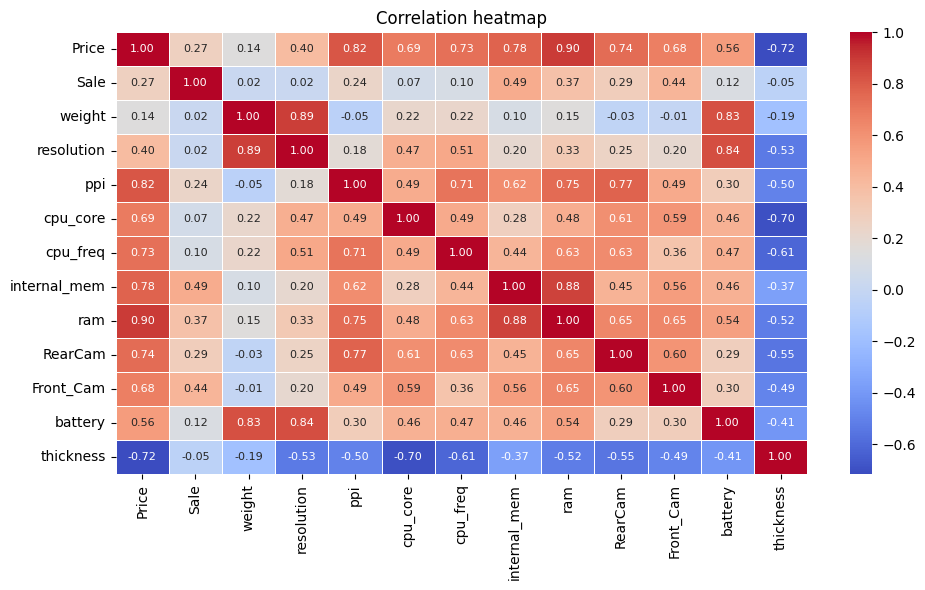

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = df.corr(numeric_only=True)
print(corr['Price'].sort_values(ascending=False))

plt.figure(figsize=(10,6))
sns.heatmap(df.drop('Product_id', axis=1).corr(), cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5,annot_kws={"size": 8})

plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()


•  Price shows strong positive correlation with several hardware features:
  ⁠◦  RAM (0.89) → Higher RAM strongly increases price.
  ⁠◦  PPI (0.82) → Higher display sharpness is associated with premium devices.
  ⁠◦  Internal Memory (0.77) → Storage capacity is a major price driver.
  ⁠◦  Rear Camera (0.74) and Front Camera (0.67) → Better camera specs increase price.
  ⁠◦  CPU Frequency (0.73) and CPU Cores (0.69) → Faster processors correlate with higher prices.
•  Battery (0.56) has a moderate positive correlation, indicating larger batteries are common in mid/high‑range phones.
•  Resolution (0.40) shows a mild positive relationship with price.
•  Sale (0.27) has a weak positive correlation, suggesting sales volume does not strongly determine price.
•  Thickness (−0.71) is strongly negatively correlated with price, meaning thinner devices tend to be more expensive.
•  Weight (0.14) and Product_id (0.16) show very weak correlations, indicating they do not meaningfully influence price.

In [75]:
df.drop('Product_id', axis=1, inplace=True)

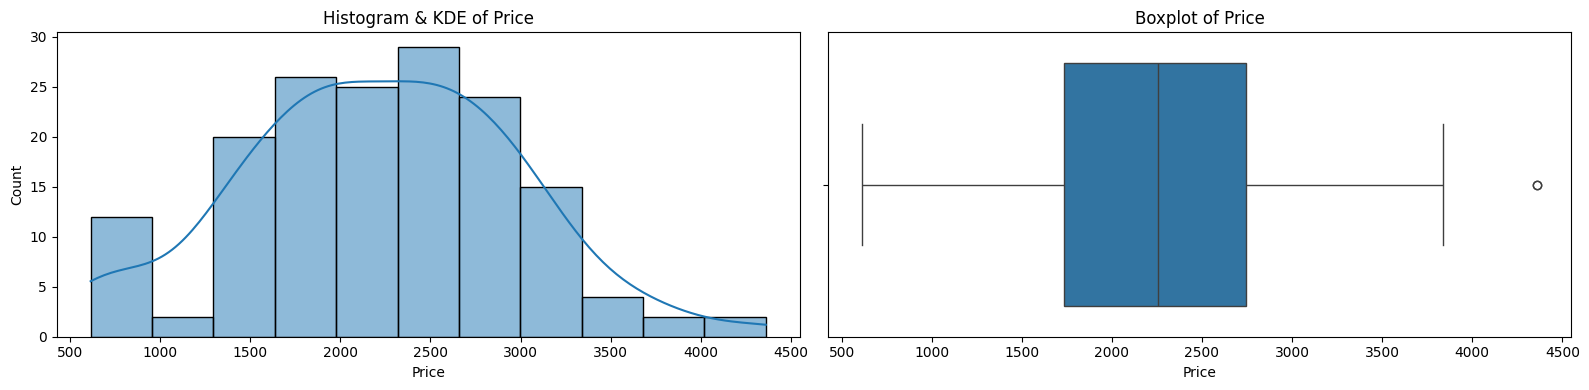

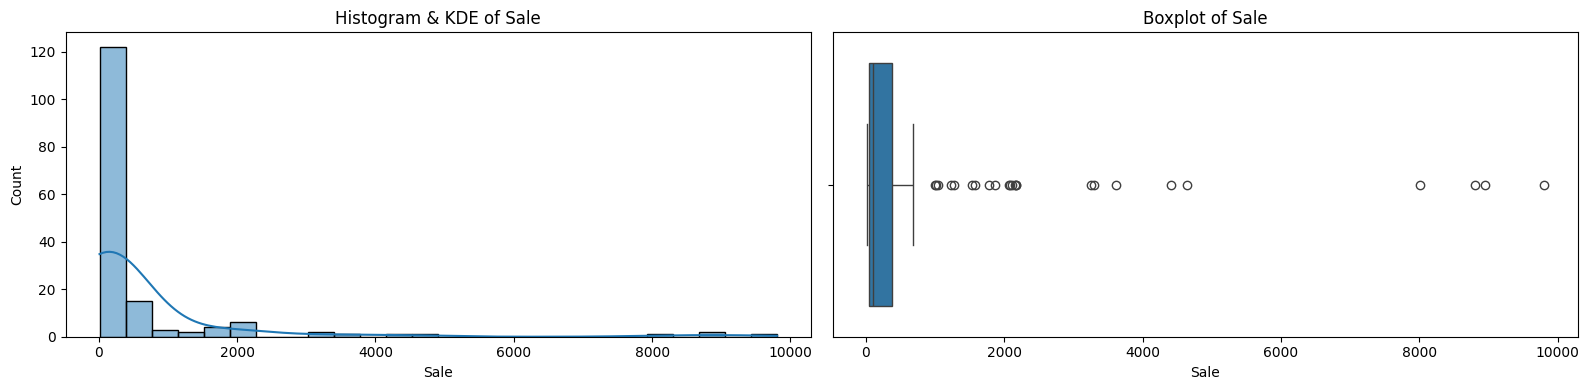

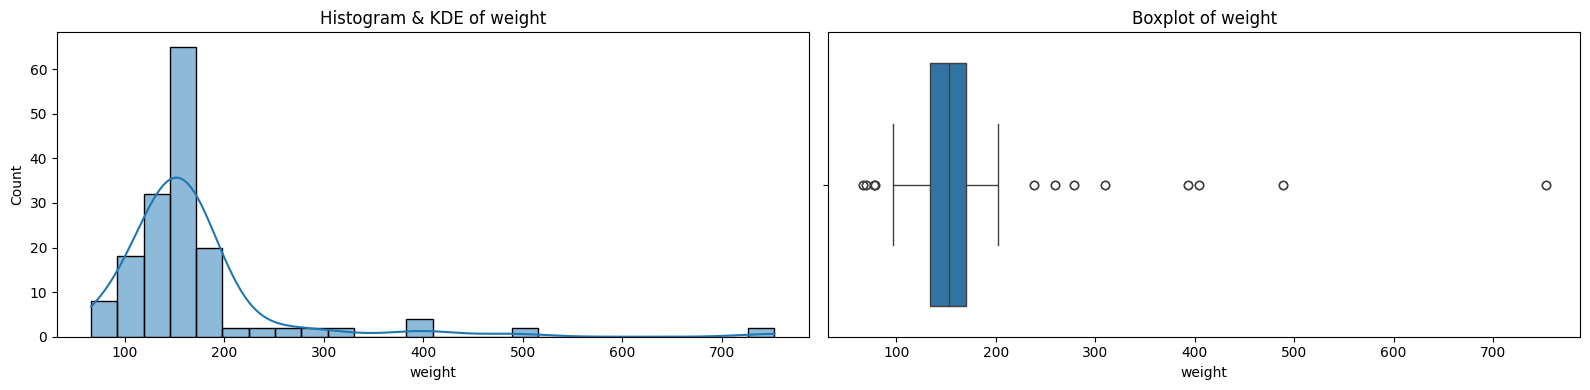

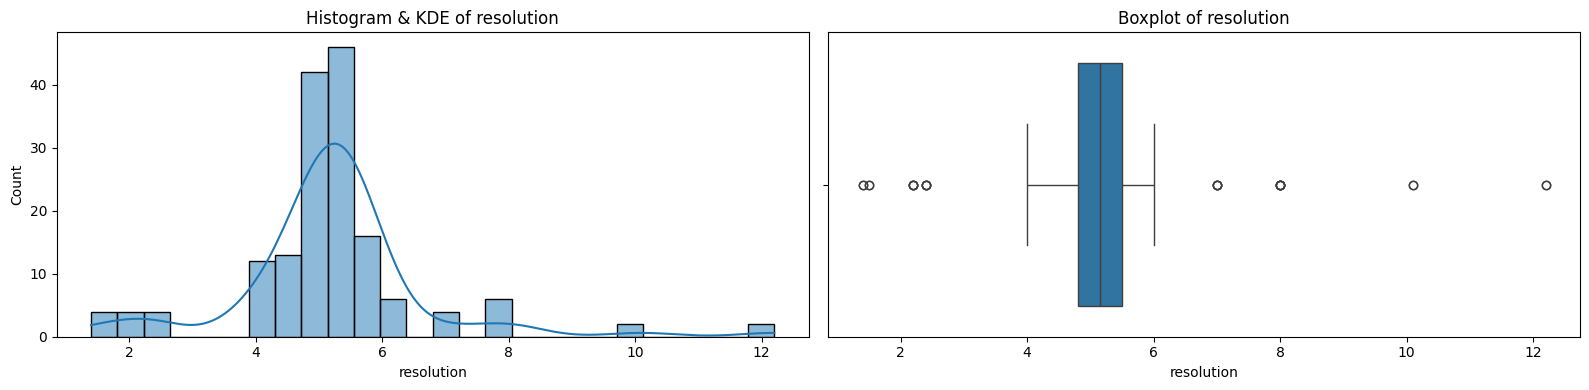

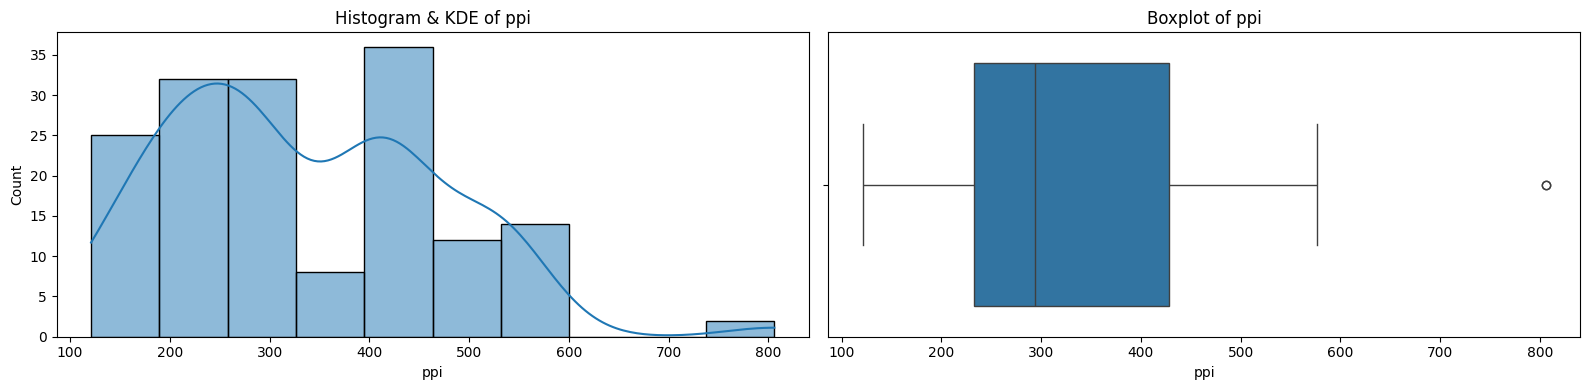

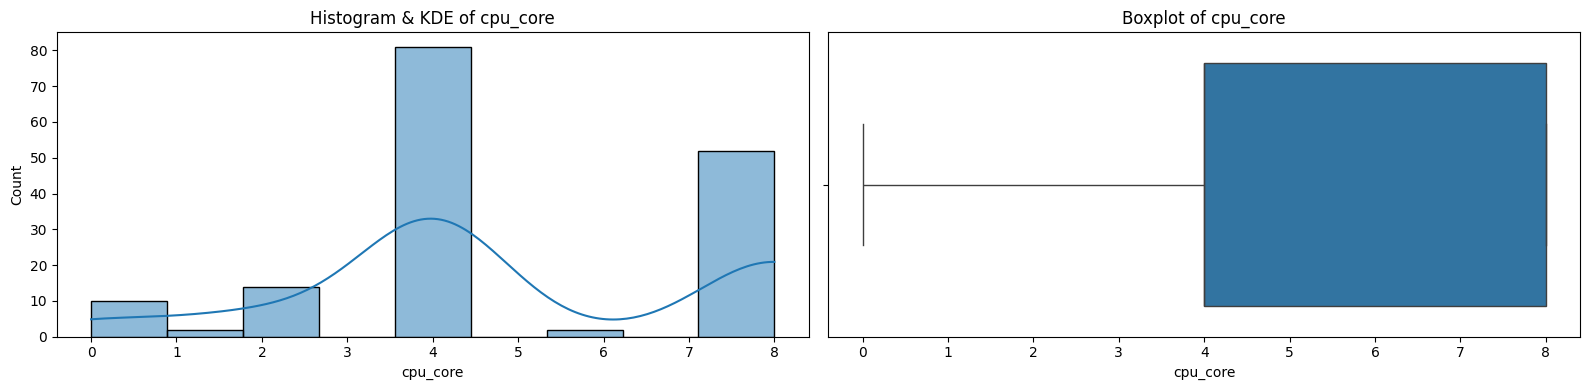

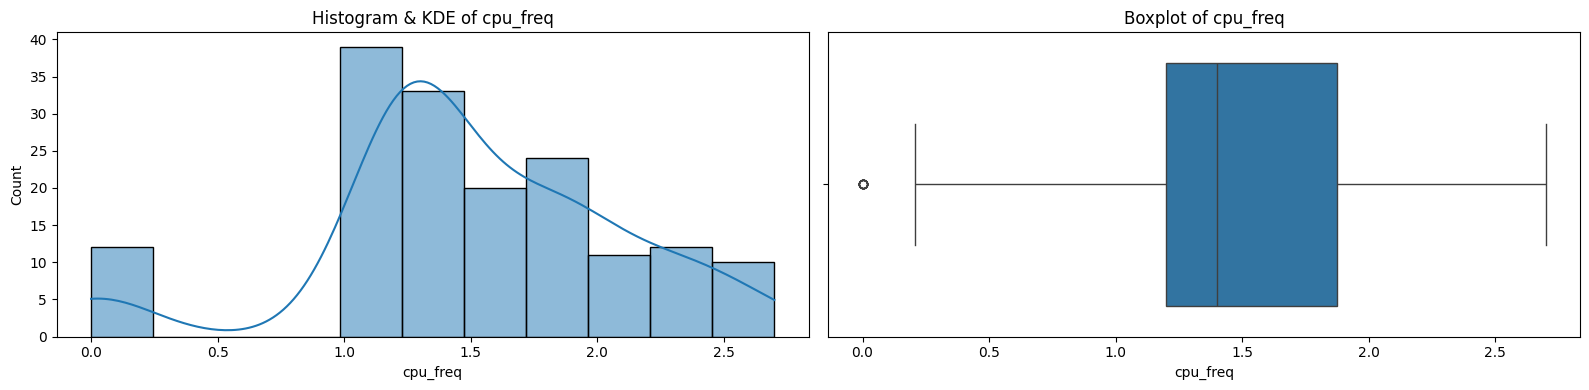

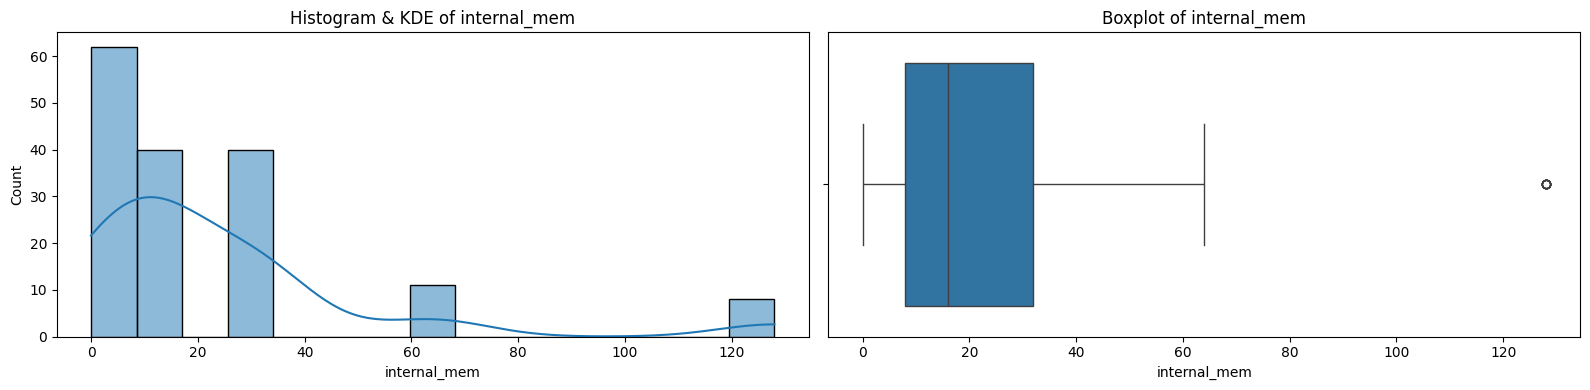

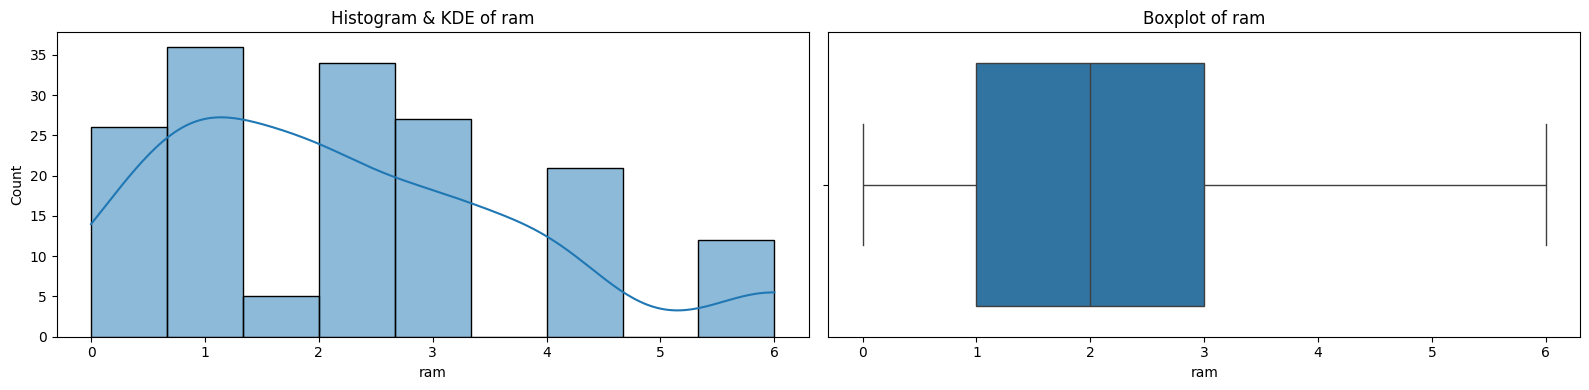

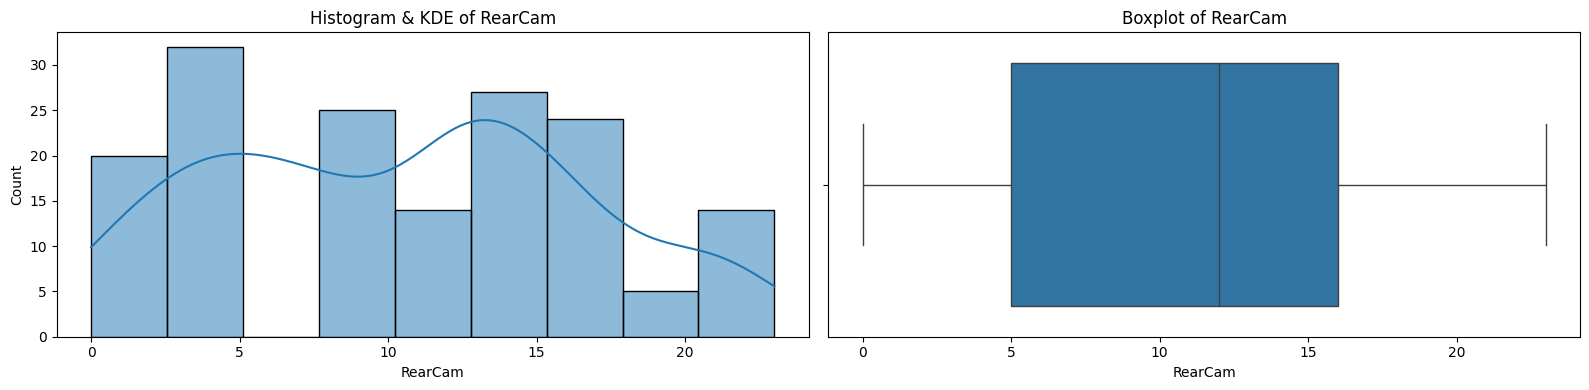

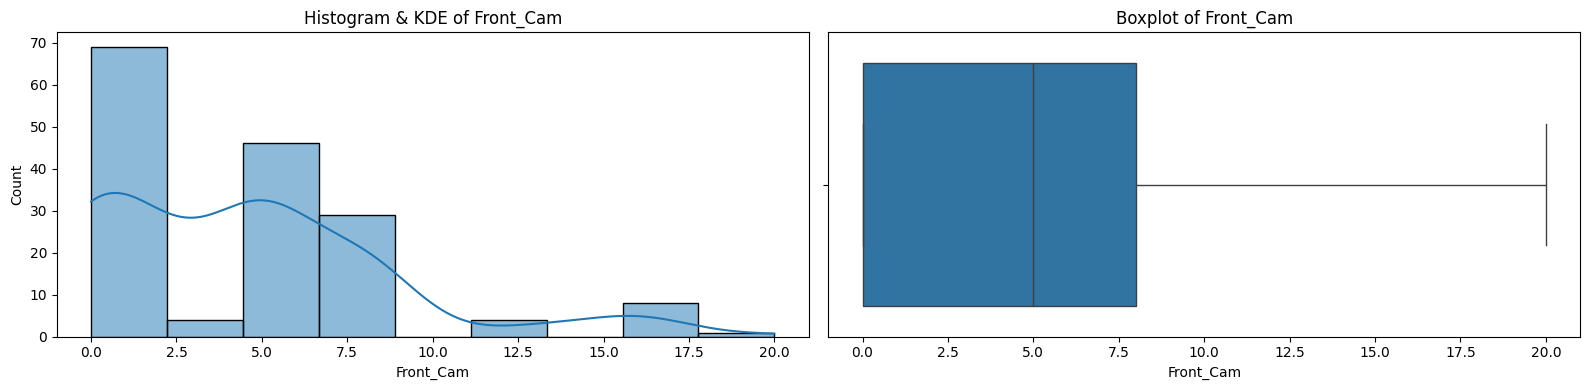

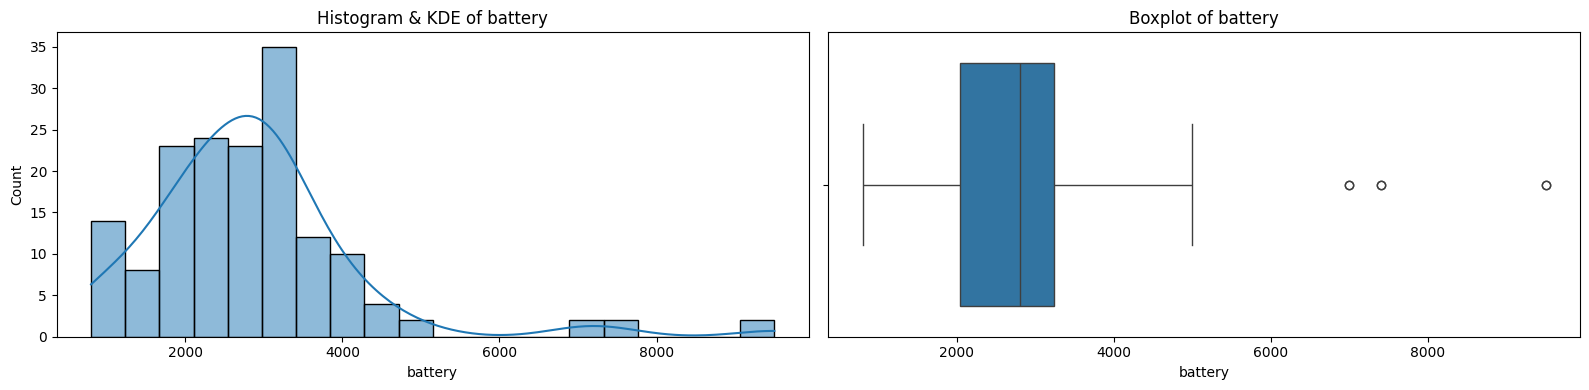

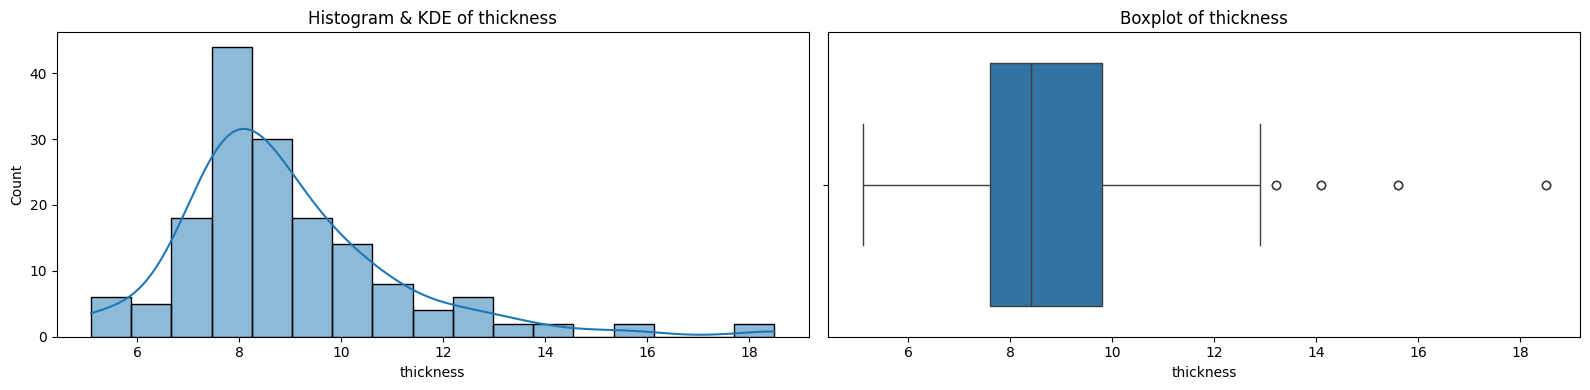

In [ ]:
num_cols = df.columns  # all numeric


for col in num_cols:
    fig,axis = plt.subplots(1,2,figsize=(16,   4))
    sns.histplot((df[col]), kde=True, ax=axis[0])
    axis[0].set_title(f"Histogram & KDE of {col}")
    plt.tight_layout()

    sns.boxplot(x=df[col], ax=axis[1])
    axis[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()



1. Skewness Observations

•  Price shows slight right‑skew due to a few high‑end devices.
•  Sale is heavily right‑skewed, indicating a long tail of very high‑sale products.
•  battery, ppi, internal_mem, and ram also show right‑skew, typical for mixed low‑end and premium devices.
•  cpu_freq and cpu_core show mild right‑skew, reflecting performance differences across models.
•  Front_Cam and RearCam show moderate right‑skew because many devices have low MP cameras, with fewer high‑MP models.
•  thickness shows slight left‑skew, meaning thinner devices are more common.

2. Outlier Insights

•  Sale contains extreme outliers (values > 5000), which can distort regression models.
•  battery has very large values (7000–9500 mAh), likely tablets or rugged devices.
•  resolution and weight show outliers corresponding to large‑screen devices.
•  internal_mem and ram include unrealistic zeros → should be treated as missing or corrected.
•  cpu_freq and cpu_core also contain zeros → invalid hardware specs.
•  thickness has a few very thick devices (> 15 mm), which are outliers.
•  Price has some high‑end outliers but remains within a reasonable range.


In [63]:
from scipy.stats import skew

skewness = df.skew()
print(skewness)

Price           0.052347
Sale            4.269384
weight          3.981756
resolution      1.176110
ppi             0.602503
cpu_core       -0.009077
cpu_freq       -0.512663
internal_mem    2.389683
ram             0.792698
RearCam         0.106929
Front_Cam       1.169750
battery         2.092660
thickness       1.587680
dtype: float64


In [77]:
#accuracy decreases if skeness removed from scipy.stats import skew

# Calculate skewness for all numeric columns
#skewness = df.skew()
#print("Skewness before transformation:\n", skewness)

# Apply log transformation to positively skewed features
#for col in df.columns:
#    if skewness[col] > 1:  # threshold for high positive skew
#        df[col] = np.log1p(df[col])  # log1p handles zero values safely

# Recheck skewness after transformation
#new_skewness = df.skew()
#print("Skewness after transformation:\n", new_skewness)

In [78]:
outlier_counts = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)

print("Outlier counts per feature:\n", outlier_counts)

Outlier counts per feature:
 {'Price': 2, 'Sale': 24, 'weight': 24, 'resolution': 26, 'ppi': 2, 'cpu_core': 0, 'cpu_freq': 10, 'internal_mem': 8, 'ram': 0, 'RearCam': 0, 'Front_Cam': 0, 'battery': 6, 'thickness': 8}


In [ ]:
# Data Cleaning - Mark false zero values as missing (NaN)

false_zero_cols = ["cpu_core", "cpu_freq", "internal_mem", "ram"]

df[false_zero_cols] = df[false_zero_cols].replace(0, np.nan)

print("\nTotal missing values in cleaned dataset:")
print(df.isnull().sum().sum())


Total missing values in cleaned dataset:
32


In [80]:

print("Missing values before filling:")
print("X_train missing values:", df.isnull().sum().sum())

median_values = df.median()

df = df.fillna(median_values)

print("\nMissing values after filling:")
print("X_train missing values:", df.isnull().sum().sum())

print("\nMedian values used for filling:")
print(median_values[false_zero_cols])

Missing values before filling:
X_train missing values: 32

Missing values after filling:
X_train missing values: 0

Median values used for filling:
cpu_core         4.0
cpu_freq         1.5
internal_mem    16.0
ram              2.0
dtype: float64


In [81]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('Price', axis=1))

In [82]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [83]:
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5)
}
X_train.view()
for name, model in models.items():
    model.fit(X_train, y_train)

    # Predict on train & test
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Print results once
    print(f"{name} | Train R²: {r2_score(y_train, y_pred_train):.3f} | "
         f"Test R²: {r2_score(y_test, y_pred_test):.3f}")

Linear | Train R²: 0.944 | Test R²: 0.951
Ridge | Train R²: 0.944 | Test R²: 0.951
Lasso | Train R²: 0.944 | Test R²: 0.951
ElasticNet | Train R²: 0.943 | Test R²: 0.948


In [70]:
from sklearn.metrics import root_mean_squared_error


results = []
for name, model in models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    results.append({
        'Model': name,
        'Train_R2': r2_score(y_train, y_pred_train),
        'Test_R2': r2_score(y_test, y_pred_test),
        'RMSE_Test': root_mean_squared_error(y_test, y_pred_test)
    })

pd.DataFrame(results)

,Model,Train_R2,Test_R2,RMSE_Test
0,Linear,0.944265,0.950809,166.991303
1,Ridge,0.944197,0.950764,167.067036
2,Lasso,0.944264,0.950828,166.959091
3,ElasticNet,0.943172,0.948274,171.238858


- based on abnove result lasso regression shows minimum RMSE, Lasso is the best model

In [87]:
import joblib
joblib.dump(models['Lasso'], 'lasso_regression_model.pkl') 
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [89]:
y_test_pred = models["Lasso"].predict(X_test)
    
test_predictions_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_test_pred
})

test_predictions_df.to_csv("test_predictions.csv", index=False)

print("test_predictions.csv created successfully")
print("Shape:", test_predictions_df.shape)

display(test_predictions_df.head())

test_predictions.csv created successfully
Shape: (33, 2)


,Actual Price,Predicted Price
0,833,1112.619288
1,1676,1870.590942
2,2508,2575.046259
3,1777,1507.219949
4,1511,1564.921860
